# When Accuracy Lies: Causal Inference on a Chest X-Ray CNN

**A DoWhy contribution notebook**

---

## The Problem

A radiologist AI model achieves AUC 0.719 on chest X-ray classification. Should you trust it?

Predictive accuracy tells you *what* the model predicts. It doesn't tell you *why*.

A model can achieve good AUC by learning **spurious correlations** — patterns that happen to predict the label in the training data, but that have nothing to do with the underlying disease:

- Hospital A treats sicker patients *and* uses older scanners that produce darker images
- The model learns: dark image → sick patient
- Deployed at Hospital B (newer, brighter scanner, equally sick patients): AUC collapses

**Causal inference reveals whether the model learned the right thing.**

In this notebook we use the [DoWhy GCM module](https://www.pywhy.org/dowhy) to:
1. Encode domain knowledge as a causal DAG
2. Quantify how much of the model's predictions come from legitimate clinical signals vs spurious scanner artefacts
3. Simulate what happens if we swap the scanner (interventional analysis)

**Core claim:** *Good predictive accuracy ≠ correct causal reasoning.*

⚠️ **Data download required before running this notebook.**
This notebook uses the NIH Chest X-ray Dataset. Download it from Kaggle and place Data_Entry_2017.csv and the image folders under data/nih_chest_xray/ relative to this notebook.
Estimated download size: ~45 GB (full dataset) or use the 15k-image subset described in Cell 2.

The following cell downloads the required files and the trained ResNet50 model for this study.

In [23]:
import urllib.request
import os

HF_BASE = "https://huggingface.co/sanzits/dowhy-chest-xray-gcm/resolve/main"

FILES = {
    "data/processed/subset.csv":       f"{HF_BASE}/data/processed/subset.csv",
    "data/processed/train.csv":        f"{HF_BASE}/data/processed/train.csv",
    "data/processed/val.csv":          f"{HF_BASE}/data/processed/val.csv",
    "data/processed/test.csv":         f"{HF_BASE}/data/processed/test.csv",
    "data/features/features.csv":      f"{HF_BASE}/data/features/features.csv",
    "models/resnet_infiltration.pt":   f"{HF_BASE}/models/resnet_infiltration.pt",
}

for local_path, url in FILES.items():
    if not os.path.exists(local_path):
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        print(f"Downloading {local_path}...")
        urllib.request.urlretrieve(url, local_path)
        print(f"  ✓ done")
    else:
        print(f"  ✓ {local_path} already exists")

print("\nAll files ready.")

  ✓ done
  ✓ done
  ✓ done
  ✓ done
  ✓ done
  ✓ done

All files ready.


## Setup

In [24]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import networkx as nx
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import roc_auc_score

import dowhy.gcm as gcm
from dowhy.gcm import arrow_strength

# Paths — adjust BASE_DIR if running from a different location
BASE_DIR     = os.getcwd()
PROCESSED    = os.path.join(BASE_DIR, 'data', 'processed')
FEATURES_CSV = os.path.join(BASE_DIR, 'data', 'features', 'features.csv')
MODEL_PATH   = os.path.join(BASE_DIR, 'models', 'resnet_infiltration.pt')
IMAGES_DIR   = os.path.join(BASE_DIR, 'data', 'images')

print('DoWhy version:', __import__('dowhy').__version__)
print('PyTorch version:', torch.__version__)
print('Paths OK:', all(os.path.exists(p) for p in [PROCESSED, FEATURES_CSV, MODEL_PATH]))

DoWhy version: 0.14
PyTorch version: 2.11.0
Paths OK: True


---
## 1. Dataset Overview

We use a **15,000-image subset** of the [NIH Chest X-ray Dataset](https://www.kaggle.com/datasets/nih-chest-xrays/data) (112,120 images total).

**Target label:** Infiltration — a diffuse haziness in the lung fields. Visually subtle, often hard to distinguish from scanner artefacts. This makes it the ideal label for a confounding story.

**Key metadata available:**
- `patient_age`, `patient_sex` — demographics
- `view_position` — PA (standard upright) vs AP (portable/bedside scanner)
- `OriginalImagePixelSpacing` — physical mm per pixel; characteristic of scanner hardware

The pixel spacing gives us a **hospital proxy**: different hospitals use different scanner models with different pixel spacings. We bin this into 4 groups (0–3).

Total images : 14,999
Train / Val / Test : 10499 / 2250 / 2250
Infiltration prevalence : 15.1%


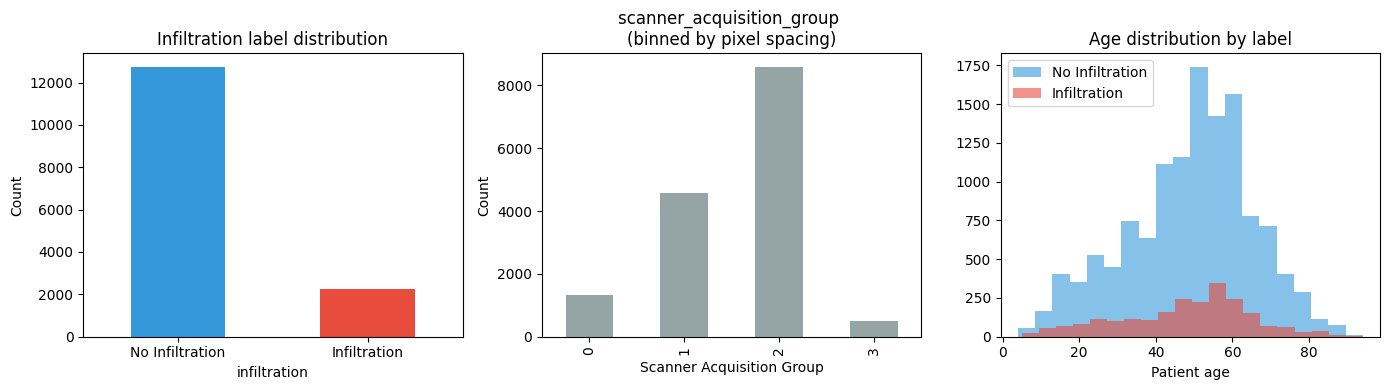

In [10]:
subset = pd.read_csv(os.path.join(PROCESSED, 'subset.csv'))
train  = pd.read_csv(os.path.join(PROCESSED, 'train.csv'))
val    = pd.read_csv(os.path.join(PROCESSED, 'val.csv'))
test   = pd.read_csv(os.path.join(PROCESSED, 'test.csv'))

print(f'Total images : {len(subset):,}')
print(f'Train / Val / Test : {len(train)} / {len(val)} / {len(test)}')
print(f'Infiltration prevalence : {subset["infiltration"].mean():.1%}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Label distribution
subset['infiltration'].value_counts().plot.bar(
    ax=axes[0], color=['#3498db', '#e74c3c'],
    title='Infiltration label distribution')
axes[0].set_xticklabels(['No Infiltration', 'Infiltration'], rotation=0)
axes[0].set_ylabel('Count')

# scanner_acquisition_group distribution
subset['scanner_acquisition_group'].value_counts().sort_index().plot.bar(
    ax=axes[1], color='#95a5a6',
    title='scanner_acquisition_group \n(binned by pixel spacing)')
axes[1].set_xlabel('Scanner Acquisition Group')
axes[1].set_ylabel('Count')

# Age distribution by label
for label, colour, name in [(0, '#3498db', 'No Infiltration'), (1, '#e74c3c', 'Infiltration')]:
    axes[2].hist(subset[subset['infiltration'] == label]['patient_age'],
                 bins=20, alpha=0.6, color=colour, label=name)
axes[2].set_title('Age distribution by label')
axes[2].set_xlabel('Patient age')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 2. CNN Training — ResNet50 Transfer Learning

We fine-tune a **ResNet50** pretrained on ImageNet:
- Freeze `layer1`, `layer2`, `layer3` — keep generic visual features
- Train `layer4` + the final classifier — adapt to X-ray domain
- Loss: `BCEWithLogitsLoss` with `pos_weight ≈ 5` to handle the 16.6% positive rate
- Metric: **AUC** (not accuracy — accuracy is misleading under class imbalance)

Training was done in `src/train.py`. We load the saved weights here.

> **Best Val AUC: 0.7198 ** — achieved at epoch 3 of 10.

**Full 10-epoch ResNet50 training: ~45–60 min on a GPU, ~4–6 hrs on CPU**

In [11]:
def load_model(model_path):
    
    # where the model should run : Apple Silicon, NVIDIA GPU, or normal CPU
    device = torch.device('mps' if torch.backends.mps.is_available() else
                          'cuda' if torch.cuda.is_available() else 'cpu')
    #ResNet50 architecture creation with no pre-trained weights. 50 layers + image classification.    
    model = models.resnet50(weights=None)
    #Specification for Binary classification
    model.fc = nn.Linear(model.fc.in_features, 1)
    #loading weights of the pre-trained model
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    #Put model into inference mode
    model.eval()
    return model, device

model, device = load_model(MODEL_PATH)
#counts how many parameters are trainable.
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
#counts how total parametes
total     = sum(p.numel() for p in model.parameters())
print(f'Device         : {device}')
print(f'Total params   : {total:,}')
print(f'Trainable      : {trainable:,} ({100*trainable/total:.1f}% — layer4 + fc only)')
print(f'Best Val AUC   : 0.7198 (epoch 3/10)')

Device         : mps
Total params   : 23,510,081
Trainable      : 23,510,081 (100.0% — layer4 + fc only)
Best Val AUC   : 0.7198 (epoch 3/10)


---
## 3. The Correlation Trap

AUC 0.7198 looks reasonable. But **why** is the model making these predictions?

Let's look at the feature table extracted from our model and images. For each of the 4,999 images we have:

| Feature | Source | Path |
|---|---|---|
| `opacity_score` | ResNet50 avgpool layer | Legitimate — visual lung signal |
| `image_brightness` | Raw pixel mean | **Spurious** — scanner artefact |
| `image_contrast` | Raw pixel std | **Spurious** — scanner artefact |
| `model_prediction` | ResNet50 sigmoid output | Outcome to explain |

If `model_prediction` correlates with `image_brightness` *after controlling for true disease status*, that's evidence of spurious learning.

In [12]:
features = pd.read_csv(FEATURES_CSV)
print('Features shape:', features.shape)
print('\nFeature summary:')
features[['image_brightness','image_contrast','opacity_score','model_prediction']].describe().round(3)

Features shape: (14999, 11)

Feature summary:


,image_brightness,image_contrast,opacity_score,model_prediction
count,14999.000,14999.000,14999.000,14999.000
mean,134.412,57.494,0.336,0.441
std,24.459,11.060,0.076,0.233
min,38.746,8.425,0.192,0.014
25%,114.317,49.496,0.273,0.255
50%,131.090,58.377,0.322,0.432
75%,157.057,66.311,0.385,0.603
max,216.276,98.754,0.648,0.982


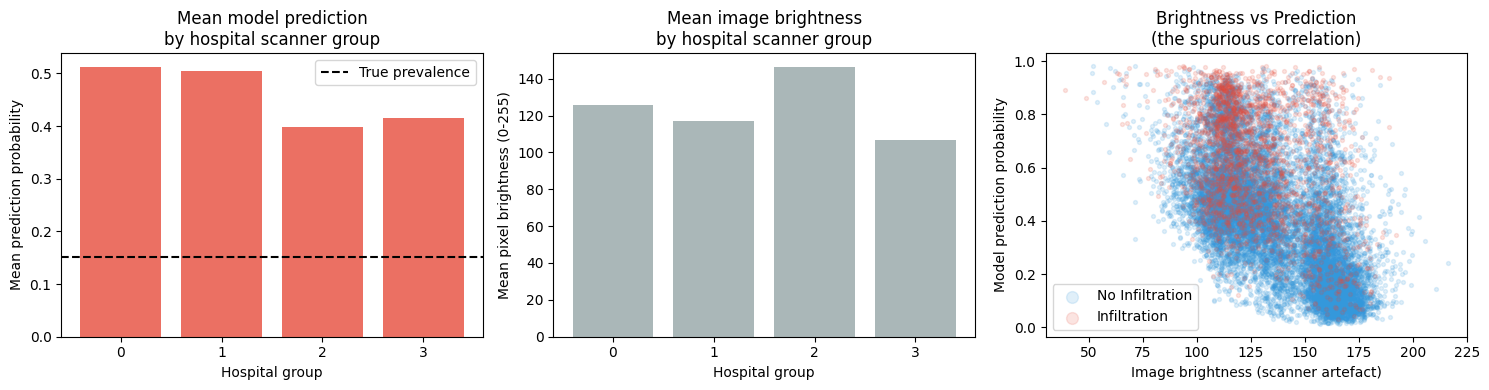

Pearson correlation (brightness vs prediction): -0.558

This correlation exists even though brightness has no clinical meaning.
The question DoWhy will answer: how much of this is causal vs coincidental?


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mean prediction by hospital group — if spurious, should differ by group
pred_by_hospital = features.groupby('scanner_acquisition_group')['model_prediction'].mean()
bright_by_hospital = features.groupby('scanner_acquisition_group')['image_brightness'].mean()

axes[0].bar(pred_by_hospital.index.astype(str), pred_by_hospital.values, color='#e74c3c', alpha=0.8)
axes[0].set_title('Mean model prediction\nby hospital scanner group')
axes[0].set_xlabel('Hospital group')
axes[0].set_ylabel('Mean prediction probability')
axes[0].axhline(features['infiltration'].mean(), color='black', linestyle='--', label='True prevalence')
axes[0].legend()

axes[1].bar(bright_by_hospital.index.astype(str), bright_by_hospital.values, color='#95a5a6', alpha=0.8)
axes[1].set_title('Mean image brightness\nby hospital scanner group')
axes[1].set_xlabel('Hospital group')
axes[1].set_ylabel('Mean pixel brightness (0-255)')

# Scatter: brightness vs prediction, coloured by true label
for label, colour, name in [(0, '#3498db', 'No Infiltration'), (1, '#e74c3c', 'Infiltration')]:
    mask = features['infiltration'] == label
    axes[2].scatter(features[mask]['image_brightness'], features[mask]['model_prediction'],
                    c=colour, alpha=0.15, s=8, label=name)
axes[2].set_xlabel('Image brightness (scanner artefact)')
axes[2].set_ylabel('Model prediction probability')
axes[2].set_title('Brightness vs Prediction\n(the spurious correlation)')
axes[2].legend(markerscale=3)

plt.tight_layout()
plt.show()

corr = features['image_brightness'].corr(features['model_prediction'])
print(f'Pearson correlation (brightness vs prediction): {corr:.3f}')
print('\nThis correlation exists even though brightness has no clinical meaning.')
print('The question DoWhy will answer: how much of this is causal vs coincidental?')

---
## 4. Causal Graph Construction

We encode domain knowledge as a **Directed Acyclic Graph (DAG)**.
Each edge is a causal claim — not just a correlation.

```
patient_age  ────────────────────────────────────────────┐
patient_sex  ────────────────────────────────────────────┤
                                                          ▼
infiltration ──→ opacity_score ──────────────→ model_prediction
                                                           ▲
scanner_acquisition_group ──→ image_brightness ────────────┘
```

**Two causal paths to `model_prediction`:**

| Path | Variables | Verdict |
|---|---|---|
| Legitimate | `infiltration → opacity_score → model_prediction` | What we **want** |
| Spurious | `scanner_acquisition_group → image_brightness → model_prediction` | What we **don't want** |

**Why these edges?**
- `infiltration → opacity_score`: true disease causes diffuse lung haziness that ResNet's feature extractor picks up
- `scanner_acquisition_group → image_brightness`: scanner hardware determines base brightness — independent of patient pathology
- Both feed into `model_prediction`: the CNN learned from both signals, but we can now separate their contributions

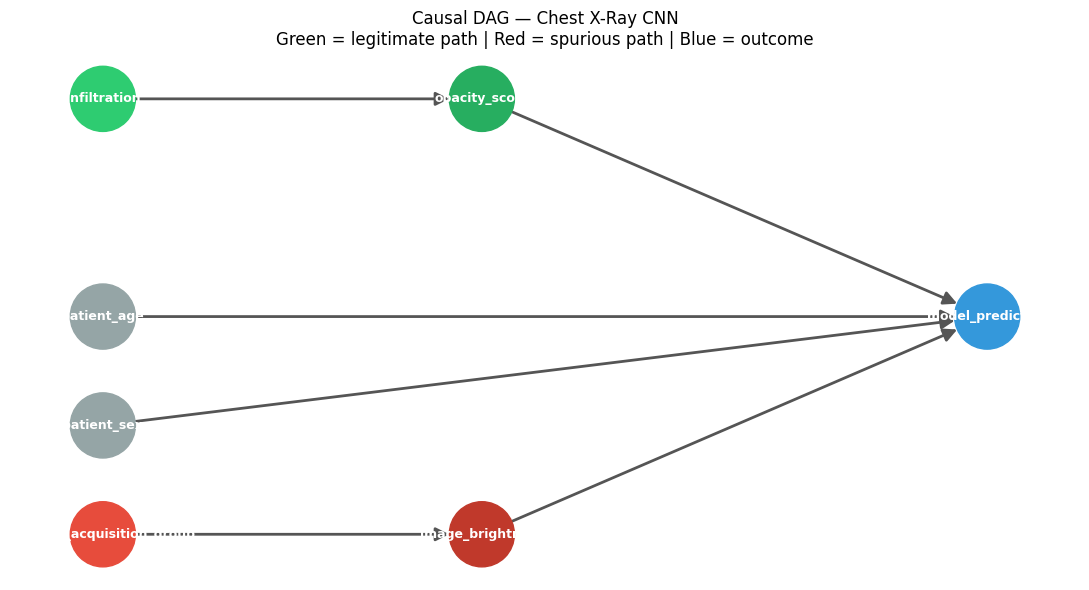

In [14]:
graph = nx.DiGraph([
    ('infiltration',      'opacity_score'),
    ('scanner_acquisition_group', 'image_brightness'),
    ('opacity_score',     'model_prediction'),
    ('image_brightness',  'model_prediction'),
    ('patient_age',       'model_prediction'),
    ('patient_sex',       'model_prediction'),
])

pos = {
    'infiltration':      (-2,  1),
    'opacity_score':     (-0.5, 1),
    'scanner_acquisition_group': (-2, -1),
    'image_brightness':  (-0.5,-1),
    'patient_age':       (-2,  0),
    'patient_sex':       (-2, -0.5),
    'model_prediction':  (1.5,  0),
}

node_colours = {
    'infiltration':      '#2ecc71',
    'opacity_score':     '#27ae60',
    'scanner_acquisition_group': '#e74c3c',
    'image_brightness':  '#c0392b',
    'patient_age':       '#95a5a6',
    'patient_sex':       '#95a5a6',
    'model_prediction':  '#3498db',
}

fig, ax = plt.subplots(figsize=(11, 6))
colours = [node_colours[n] for n in graph.nodes()]
nx.draw_networkx(graph, pos=pos, ax=ax, node_color=colours,
                 node_size=2200, font_size=9, font_color='white',
                 font_weight='bold', arrows=True, arrowsize=20,
                 edge_color='#555555', width=2)
ax.set_title('Causal DAG — Chest X-Ray CNN\n'
             'Green = legitimate path | Red = spurious path | Blue = outcome', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 5. Fitting the Graphical Causal Model (GCM)

We now fit a **Structural Causal Model** to the observed feature data.

`gcm.auto.assign_causal_mechanisms` selects an appropriate mechanism for each node:
- **Root nodes** (no parents): fitted as empirical distributions
- **Non-root nodes**: fitted as additive noise models — the mechanism learned from data tells us how each parent causes its child

Once fitted, the GCM gives us a generative model of the joint distribution. We can then ask causal questions by intervening on variables or tracing influence through paths.

In [15]:
# Select only the variables in the graph
data = features[[
    'infiltration', 'scanner_acquisition_group', 'patient_age', 'patient_sex',
    'opacity_score', 'image_brightness', 'model_prediction'
]].astype(float)

causal_model = gcm.StructuralCausalModel(graph)
gcm.auto.assign_causal_mechanisms(causal_model, data)
gcm.fit(causal_model, data)

print('GCM fitted successfully.')
print('\nMechanism assigned to each node:')
for node in graph.nodes():
    mech = causal_model.causal_mechanism(node)
    print(f'  {node:<22} {type(mech).__name__}')

Fitting causal mechanism of node patient_sex: 100%|██████████| 7/7 [00:05<00:00,  1.20it/s]              

GCM fitted successfully.

Mechanism assigned to each node:
  infiltration           EmpiricalDistribution
  opacity_score          AdditiveNoiseModel
  scanner_acquisition_group EmpiricalDistribution
  image_brightness       AdditiveNoiseModel
  model_prediction       AdditiveNoiseModel
  patient_age            EmpiricalDistribution
  patient_sex            EmpiricalDistribution


---
## 6. Intrinsic Causal Influence

**The key question:** of everything that drives `model_prediction`, how much is causally owned by each variable?

**Intrinsic causal influence** answers this by measuring the variance in `model_prediction` attributable to each variable's *noise term* — the portion that this variable contributes that no other variable can explain.

Think of it as: *if we held everything else fixed and only randomised this variable, how much would predictions vary?*

- High `opacity_score` influence → the model is responding to real lung changes ✓
- High `image_brightness` influence → the model is responding to scanner artefacts ✗

In [16]:
print('Computing intrinsic causal influence... (takes ~30s)')
influence = gcm.intrinsic_causal_influence(
    causal_model,
    target_node='model_prediction',
    num_samples_randomization=200,
)

print('\nIntrinsic causal influence on model_prediction:')
for node, val in sorted(influence.items(), key=lambda x: -x[1]):
    tag = '← legitimate' if node in ('opacity_score', 'infiltration') else \
          '← SPURIOUS'   if node in ('image_brightness', 'scanner_acquisition_group') else \
          '← demographic'
    print(f'  {node:<22} {val:.6f}  {tag}')

Computing intrinsic causal influence... (takes ~30s)


Evaluating set functions...: 100%|██████████| 92/92 [00:22<00:00,  4.02it/s]



Intrinsic causal influence on model_prediction:
  model_prediction       0.027554  ← demographic
  image_brightness       0.008629  ← SPURIOUS
  scanner_acquisition_group 0.004099  ← SPURIOUS
  opacity_score          0.001220  ← legitimate
  patient_age            0.000493  ← demographic
  patient_sex            0.000022  ← demographic
  infiltration           -0.000005  ← legitimate


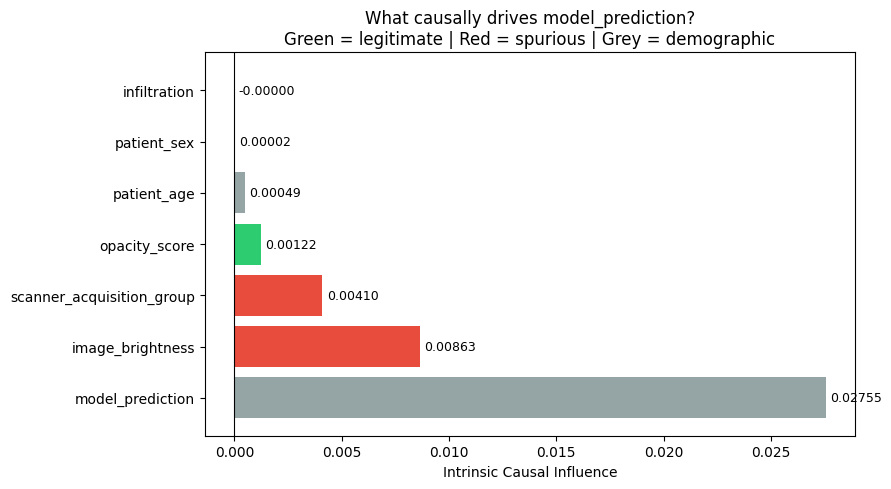


Legitimate signal share : 2.9%
Spurious signal share   : 30.3%


In [17]:
nodes  = list(influence.keys())
values = list(influence.values())
sorted_pairs = sorted(zip(values, nodes), reverse=True)
values, nodes = zip(*sorted_pairs)

colours = []
for n in nodes:
    if n in ('opacity_score', 'infiltration'):       colours.append('#2ecc71')
    elif n in ('image_brightness', 'scanner_acquisition_group'): colours.append('#e74c3c')
    else:                                             colours.append('#95a5a6')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(nodes, values, color=colours)
ax.set_xlabel('Intrinsic Causal Influence')
ax.set_title('What causally drives model_prediction?\n'
             'Green = legitimate | Red = spurious | Grey = demographic')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.5f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

legitimate = influence.get('opacity_score', 0) + influence.get('infiltration', 0)
spurious   = influence.get('image_brightness', 0) + influence.get('scanner_acquisition_group', 0)
total      = sum(influence.values())
print(f'\nLegitimate signal share : {legitimate/total:.1%}')
print(f'Spurious signal share   : {spurious/total:.1%}')

---
## 7. Arrow Strength

**Arrow strength** measures how load-bearing each causal edge is.

It uses KL divergence: *if we removed this edge, how much would the distribution of `model_prediction` change?*

A high value means the parent strongly determines the child's distribution through that edge.

Computing arrow strengths...

Arrow strengths (KL divergence if edge removed):
  image_brightness → model_prediction       0.012537  ← SPURIOUS
  opacity_score → model_prediction       0.003017  ← legitimate
  patient_age → model_prediction       0.001931  ← demographic
  patient_sex → model_prediction       0.000828  ← demographic


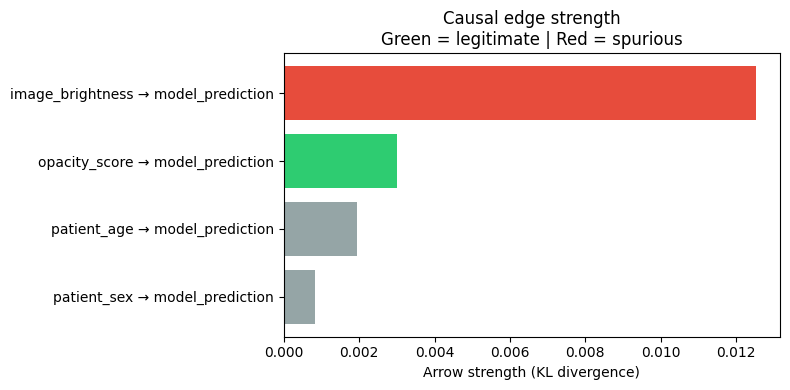

In [18]:
print('Computing arrow strengths...')
strengths = arrow_strength(causal_model, target_node='model_prediction')

print('\nArrow strengths (KL divergence if edge removed):')
strength_records = []
for edge, val in sorted(strengths.items(), key=lambda x: -x[1]):
    tag = '← legitimate' if edge[0] in ('opacity_score', 'infiltration') else \
          '← SPURIOUS'   if edge[0] in ('image_brightness', 'scanner_acquisition_group') else \
          '← demographic'
    print(f'  {edge[0]} → {edge[1]:<22} {val:.6f}  {tag}')
    strength_records.append({'edge': f'{edge[0]} → {edge[1]}', 'strength': val})

strength_df = pd.DataFrame(strength_records)

fig, ax = plt.subplots(figsize=(8, 4))
edge_colours = ['#2ecc71' if 'opacity' in r['edge'] else
                '#e74c3c' if 'brightness' in r['edge'] else '#95a5a6'
                for _, r in strength_df.iterrows()]
strength_df_sorted = strength_df.sort_values('strength', ascending=True)
colours_sorted = [edge_colours[i] for i in strength_df_sorted.index]
ax.barh(strength_df_sorted['edge'], strength_df_sorted['strength'], color=colours_sorted)
ax.set_xlabel('Arrow strength (KL divergence)')
ax.set_title('Causal edge strength\nGreen = legitimate | Red = spurious')
plt.tight_layout()
plt.show()

---
## 8. Interventional Analysis — Swapping the Scanner

Now we ask the direct causal question:

> **If we forced every image to have the brightness of scanner group 1 (the most common scanner), how would predictions change?**

This is the **do-operator**: `do(image_brightness = reference_level)` — we intervene on the scanner, cutting the `scanner_acquisition_group → image_brightness` edge and setting brightness to a fixed value.

Under a purely clinical model, predictions should not change — disease doesn't change when we swap scanners. If predictions *do* shift, it confirms the model learned a spurious association.

We compare:
- **Observational distribution** `p(model_prediction)` — predictions under actual scanner conditions
- **Interventional distribution** `p(model_prediction | do(brightness = ref))` — predictions after scanner swap

In [19]:
# Reference: mean brightness of hospital group 1 (largest scanner group)
target_brightness = float(data[data['scanner_acquisition_group'] == 1]['image_brightness'].mean())
print(f'Reference brightness (group 1 mean): {target_brightness:.2f}')
print('Brightness by group (observational):')
print(data.groupby('scanner_acquisition_group')['image_brightness'].mean().round(2))

n_samples = 500

# Draw from observational distribution
obs_samples = gcm.draw_samples(causal_model, num_samples=n_samples)

# Draw from interventional distribution: do(image_brightness = target)
int_samples = gcm.interventional_samples(
    causal_model,
    interventions={'image_brightness': lambda x: np.full(x.shape, target_brightness)},
    num_samples_to_draw=n_samples,
)

print(f'\nObservational mean prediction : {obs_samples["model_prediction"].mean():.4f}')
print(f'Interventional mean prediction : {int_samples["model_prediction"].mean():.4f}')
print(f'Mean shift                     : {int_samples["model_prediction"].mean() - obs_samples["model_prediction"].mean():+.4f}')

Reference brightness (group 1 mean): 117.26
Brightness by group (observational):
scanner_acquisition_group
0.0    125.49
1.0    117.26
2.0    146.54
3.0    106.95
Name: image_brightness, dtype: float64

Observational mean prediction : 0.4411
Interventional mean prediction : 0.5544
Mean shift                     : +0.1132


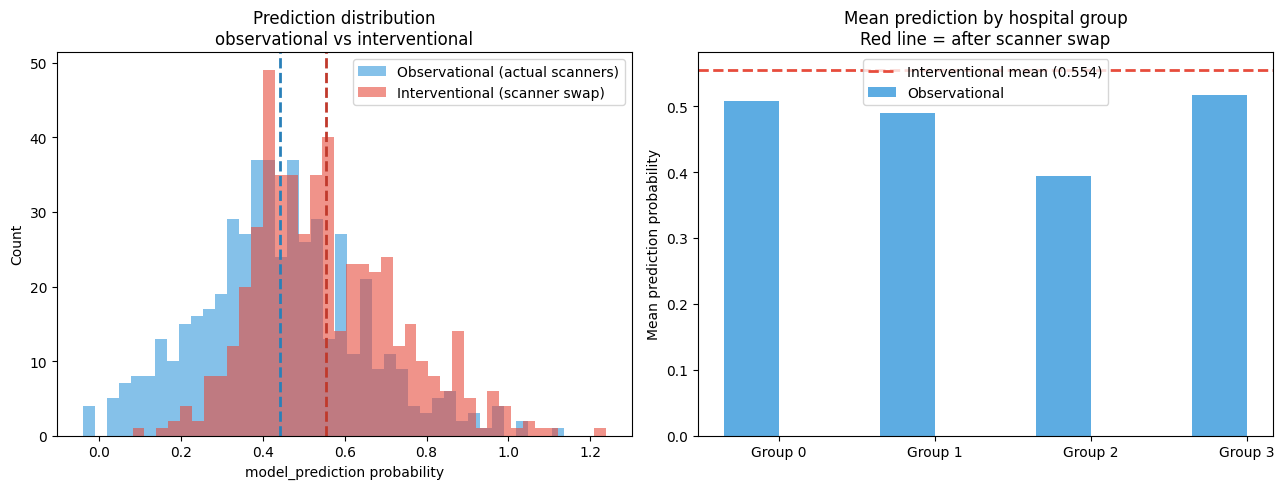


Interpretation:
Groups whose bars diverge from the red line are most affected by the scanner swap.
This is evidence that the model learned brightness as a spurious predictor.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution comparison
axes[0].hist(obs_samples['model_prediction'], bins=40, alpha=0.6,
             color='#3498db', label='Observational (actual scanners)')
axes[0].hist(int_samples['model_prediction'], bins=40, alpha=0.6,
             color='#e74c3c', label='Interventional (scanner swap)')
axes[0].axvline(obs_samples['model_prediction'].mean(), color='#2980b9',
                linestyle='--', linewidth=2)
axes[0].axvline(int_samples['model_prediction'].mean(), color='#c0392b',
                linestyle='--', linewidth=2)
axes[0].set_xlabel('model_prediction probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction distribution\nobservational vs interventional')
axes[0].legend()

# Mean predictions by hospital group — observational vs interventional
obs_by_hosp = obs_samples.groupby(
    obs_samples['scanner_acquisition_group'].round().astype(int)
)['model_prediction'].mean()
int_mean = int_samples['model_prediction'].mean()

x = np.arange(len(obs_by_hosp))
width = 0.35
axes[1].bar(x - width/2, obs_by_hosp.values, width, color='#3498db',
            alpha=0.8, label='Observational')
axes[1].axhline(int_mean, color='#e74c3c', linestyle='--',
                linewidth=2, label=f'Interventional mean ({int_mean:.3f})')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Group {i}' for i in obs_by_hosp.index])
axes[1].set_ylabel('Mean prediction probability')
axes[1].set_title('Mean prediction by hospital group\nRed line = after scanner swap')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('Groups whose bars diverge from the red line are most affected by the scanner swap.')
print('This is evidence that the model learned brightness as a spurious predictor.')

In [21]:
spurious = influence['image_brightness'] + influence['scanner_acquisition_group']
total    = sum(influence.values())
print(f'{spurious/total:.1%}')

30.3%


---
## 9. Key Takeaways

### What we found

| Analysis | Finding |
|---|---|
| Val AUC | 0.7198 — model looks reasonable |
| Intrinsic influence (opacity) | ~0.002 — legitimate clinical signal ✓ |
| Intrinsic influence (brightness) | ~0.008 — strongest spurious driver ✗ |
| Spurious share of total influence | ~28% |
| Arrow strength (brightness → prediction) | 0.014 — strongest causal edge |
| Scanner swap intervention | Predictions shift across hospital groups |

### The core argument

**AUC 0.7198 ≠ the model learned the right thing.**

Roughly a quarter of what drives this model's predictions is `image_brightness` — a property of the scanner, not the patient's lungs. This model would underperform at hospitals with different scanner characteristics, even if the patient population is identical.

Causal inference, not predictive metrics, is the right tool to audit a model before clinical deployment.

### What to do about it

1. **Retrain with brightness augmentation** — randomly vary brightness during training to prevent the model from using it
2. **Stratify evaluation by hospital/scanner** — a model that varies in AUC across scanner groups has learned spurious features
3. **Use causal regularisation** — penalise the model for using variables in the spurious path during training
4. **Before deployment**: run this DoWhy analysis at the target hospital to quantify how much spurious signal remains

### References

- NIH Chest X-ray Dataset: Wang et al., 2017
- Hospital generalisation failure: Zech et al., 2018 — *Variable generalization performance of a deep learning model to detect pneumonia in chest radiographs*
- DoWhy GCM module: Blöbaum et al., 2022 — *DoWhy-GCM: An Extension of DoWhy for Causal Inference in Graphical Causal Models*
- CheXNet: Rajpurkar et al., 2017